In [1]:
from google.colab import files

uploaded = files.upload()  # choose your ZIP file


Saving DL_Assignment1_Dataset.zip to DL_Assignment1_Dataset.zip


In [2]:
import zipfile, os

# If uploaded manually, replace with your uploaded filename
zip_path = "/content/DL_Assignment1_Dataset.zip"

extract_dir = "/content/"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print("✅ Extracted to:", extract_dir)

!ls -R {extract_dir} | head -40   # preview first 40 lines of structure


✅ Extracted to: /content/
/content/:
Dataset
DL_Assignment1_Dataset.zip
sample_data

/content/Dataset:
Dataset

/content/Dataset/Dataset:
annotations
images

/content/Dataset/Dataset/annotations:
0_aro.npy
0_exp.npy
0_lnd.npy
0_val.npy
1001_aro.npy
1001_exp.npy
1001_lnd.npy
1001_val.npy
1002_aro.npy
1002_exp.npy
1002_lnd.npy
1002_val.npy
1003_aro.npy
1003_exp.npy
1003_lnd.npy
1003_val.npy
1007_aro.npy
1007_exp.npy
1007_lnd.npy
1007_val.npy
1008_aro.npy
1008_exp.npy
1008_lnd.npy
1008_val.npy
1009_aro.npy
1009_exp.npy
1009_lnd.npy


In [3]:
from pathlib import Path
import numpy as np
import os

ROOT = Path("/content/Dataset/Dataset")  # base folder after unzip

img_dir = ROOT / "images"

ann_dir = ROOT / "annotations"


In [4]:
img_files, exp_labels, val_labels, aro_labels = [], [], [], []

for fname in sorted(img_dir.glob("*.jpg")):
    img_id = fname.stem  # "0", "1001", ...
    exp_path = ann_dir / f"{img_id}_exp.npy"
    val_path = ann_dir / f"{img_id}_val.npy"
    aro_path = ann_dir / f"{img_id}_aro.npy"

    if exp_path.exists() and val_path.exists() and aro_path.exists():
        img_files.append(str(fname))
        exp_labels.append(np.load(exp_path).item() if np.load(exp_path).shape == () else np.load(exp_path)[()])
        val_labels.append(np.load(val_path).item() if np.load(val_path).shape == () else np.load(val_path)[()])
        aro_labels.append(np.load(aro_path).item() if np.load(aro_path).shape == () else np.load(aro_path)[()])

X = np.array(img_files)
y_exp = np.array(exp_labels, dtype=np.int32)
y_val = np.array(val_labels, dtype=np.float32)
y_aro = np.array(aro_labels, dtype=np.float32)

num_classes = len(np.unique(y_exp))

print("✅ Dataset loaded")
print("Images:", X.shape)
print("Expressions:", y_exp.shape, "Val:", y_val.shape, "Aro:", y_aro.shape)
print("Number of classes:", num_classes)


✅ Dataset loaded
Images: (3999,)
Expressions: (3999,) Val: (3999,) Aro: (3999,)
Number of classes: 8


In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(X, y_exp))

X_train, X_val = X[train_idx], X[val_idx]
yexp_train, yexp_val = y_exp[train_idx], y_exp[val_idx]
yval_train, yval_val = y_val[train_idx], y_val[val_idx]
yaro_train, yaro_val = y_aro[train_idx], y_aro[val_idx]

print("Train:", X_train.shape, "Val:", X_val.shape)


Train: (3199,) Val: (800,)


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0, VGG16
import numpy as np
from pathlib import Path

# --- Config ---
IMG_SIZE = (224, 224)
BATCH = 16   # smaller batch to save RAM
SEED = 42

root = Path("/content/Dataset/Dataset")
img_dir = root / "images"
ann_dir = root / "annotations"

# --- Collect image paths & labels ---
img_paths, exp_labels, va_labels = [], [], []

for img_file in sorted(img_dir.glob("*.jpg")):
    stem = img_file.stem
    exp_path, val_path, aro_path = ann_dir/f"{stem}_exp.npy", ann_dir/f"{stem}_val.npy", ann_dir/f"{stem}_aro.npy"
    if exp_path.exists() and val_path.exists() and aro_path.exists():
        img_paths.append(str(img_file))
        exp_labels.append(np.load(exp_path).item())
        va_labels.append([np.load(val_path).item(), np.load(aro_path).item()])

img_paths = np.array(img_paths)
exp_labels = np.array(exp_labels, dtype=np.int32)
va_labels  = np.array(va_labels, dtype=np.float32)

num_classes = int(np.max(exp_labels)) + 1
print(f"✅ Loaded {len(img_paths)} samples | {num_classes} classes")

# --- Train/Val split ---
from sklearn.model_selection import train_test_split
X_train, X_val, yexp_train, yexp_val, yva_train, yva_val = train_test_split(
    img_paths, exp_labels, va_labels, test_size=0.2, stratify=exp_labels, random_state=SEED
)

# --- TF Dataset builder ---
def make_ds(paths, yexp, yva, training=True):

    ds = tf.data.Dataset.from_tensor_slices((paths, (yexp, yva)))

    def _load(path, labels):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.image.convert_image_dtype(img, tf.float32)
        return img, labels

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.05),
        ])
        ds = ds.map(lambda x,y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

ds_train = make_ds(X_train, yexp_train, yva_train, training=True)
ds_val   = make_ds(X_val, yexp_val, yva_val, training=False)


✅ Loaded 3999 samples | 8 classes


In [7]:
def build_efficientnet(input_shape=(224,224,3), num_classes=8):
    base = EfficientNetB0(include_top=False, input_shape=input_shape, weights="imagenet")
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    exp_out = layers.Dense(num_classes, activation="softmax", name="exp")(x)
    va_out  = layers.Dense(2, activation="linear", name="va")(x)
    return Model(base.input, [exp_out, va_out]), base

def build_vgg16(input_shape=(224,224,3), num_classes=8):
    base = VGG16(include_top=False, input_shape=input_shape, weights="imagenet")
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    exp_out = layers.Dense(num_classes, activation="softmax", name="exp")(x)
    va_out  = layers.Dense(2, activation="linear", name="va")(x)
    return Model(base.input, [exp_out, va_out]), base


In [8]:
from tensorflow import keras

def train_light(model, base, tag, epochs=10):
    opt = keras.optimizers.Adam(1e-4)
    model.compile(
        optimizer=opt,
        loss={"exp": keras.losses.SparseCategoricalCrossentropy(),
              "va": keras.losses.MeanSquaredError()},
        loss_weights={"exp": 1.0, "va": 0.5},
        metrics={"exp": ["accuracy"], "va": ["mse"]}
    )
    ckpt = f"/content/{tag}.keras"
    cbs = [keras.callbacks.ModelCheckpoint(ckpt, save_best_only=True, monitor="val_exp_accuracy")]
    hist = model.fit(ds_train, validation_data=ds_val, epochs=epochs, callbacks=cbs, verbose=1)
    return keras.models.load_model(ckpt), hist


In [9]:
from tensorflow.keras.applications import EfficientNetB0, VGG16
from tensorflow.keras import Model, layers

def build_efficientnet(input_shape=(224,224,3), num_classes=8):
    base = EfficientNetB0(include_top=False, input_shape=input_shape, weights="imagenet")
    base.trainable = False  # start frozen

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)

    exp_out = layers.Dense(num_classes, activation="softmax", name="exp")(x)
    va_out  = layers.Dense(2, activation="linear", name="va")(x)

    model = Model(inputs=base.input, outputs=[exp_out, va_out], name="EfficientNetB0_MultiTask")
    return model, base

def build_vgg16(input_shape=(224,224,3), num_classes=8):
    base = VGG16(include_top=False, input_shape=input_shape, weights="imagenet")
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)

    exp_out = layers.Dense(num_classes, activation="softmax", name="exp")(x)
    va_out  = layers.Dense(2, activation="linear", name="va")(x)

    model = Model(inputs=base.input, outputs=[exp_out, va_out], name="VGG16_MultiTask")
    return model, base


In [10]:
import  numpy as np

In [11]:
num_classes = int(np.max(y_exp)) + 1
print("Number of expression classes:", num_classes)


Number of expression classes: 8


In [13]:
# EfficientNetB0
eff_model, eff_base = build_efficientnet((224,224,3), num_classes)
best_eff, eff_hist = train_light(eff_model, eff_base, "eff_light", epochs=35)


Epoch 1/35
200/200 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - exp_accuracy: 0.1516 - exp_loss: 2.1410 - loss: 2.3360 - va_loss: 0.3900 - va_mse: 0.3900 - val_exp_accuracy: 0.1600 - val_exp_loss: 2.0893 - val_loss: 2.2032 - val_va_loss: 0.2278 - val_va_mse: 0.2278
Epoch 2/35
200/200 ━━━━━━━━━━━━━━━━━━━━ 53s 119ms/step - exp_accuracy: 0.1500 - exp_loss: 2.0966 - loss: 2.2445 - va_loss: 0.2958 - va_mse: 0.2958 - val_exp_accuracy: 0.1912 - val_exp_loss: 2.0453 - val_loss: 2.1523 - val_va_loss: 0.2140 - val_va_mse: 0.2140
Epoch 3/35
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - exp_accuracy: 0.1835 - exp_loss: 2.0574 - loss: 2.1969 - va_loss: 0.2789 - va_mse: 0.2789 - val_exp_accuracy: 0.1963 - val_exp_loss: 2.0141 - val_loss: 2.1157 - val_va_loss: 0.2032 - val_va_mse: 0.2032
Epoch 4/35
200/200 ━━━━━━━━━━━━━━━━━━━━ 34s 126ms/step - exp_accuracy: 0.2023 - exp_loss: 2.0256 - loss: 2.1624 - va_loss: 0.2735 - va_mse: 0.2735 - val_exp_accuracy: 0.2050 - val_exp_loss: 1.9925 - val_loss: 2.0916 - val_v

In [14]:

# VGG16
vgg_model, vgg_base = build_vgg16((224,224,3), num_classes)
best_vgg, vgg_hist = train_light(vgg_model, vgg_base, "vgg_light", epochs=40)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 74s 266ms/step - exp_accuracy: 0.1364 - exp_loss: 8.1004 - loss: 24.5489 - va_loss: 32.8970 - va_mse: 32.8969 - val_exp_accuracy: 0.1425 - val_exp_loss: 5.0562 - val_loss: 11.7651 - val_va_loss: 13.4178 - val_va_mse: 13.4178
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 215ms/step - exp_accuracy: 0.1357 - exp_loss: 6.4773 - loss: 17.2768 - va_loss: 21.5990 - va_mse: 21.5990 - val_exp_accuracy: 0.1637 - val_exp_loss: 4.7219 - val_loss: 9.8258 - val_va_loss: 10.2079 - val_va_mse: 10.2079
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 215ms/step - exp_accuracy: 0.1570 - exp_loss: 6.0893 - loss: 15.1942 - va_loss: 18.2098 - va_mse: 18.2097 - val_exp_accuracy: 0.1737 - val_exp_loss: 4.3881 - val_loss: 8.5247 - val_va_loss: 8.2732 - val_va_mse: 8.2732
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 215ms/step - exp_accuracy: 0.1567 - exp_loss: 5.7716 - loss: 13.7088 - va_loss: 15.8746 - va_mse: 15.8745 - val_ex

In [15]:
print("🔹 EfficientNetB0 Evaluation:")
best_eff.evaluate(ds_val)

print("\n🔹 VGG16 Evaluation:")
best_vgg.evaluate(ds_val)


🔹 EfficientNetB0 Evaluation:
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - exp_accuracy: 0.2570 - exp_loss: 1.8565 - loss: 1.9354 - va_loss: 0.1578 - va_mse: 0.1578

🔹 VGG16 Evaluation:
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - exp_accuracy: 0.3214 - exp_loss: 2.0090 - loss: 2.1223 - va_loss: 0.2266 - va_mse: 0.2266


[2.1620333194732666,
 2.0466737747192383,
 0.2307179868221283,
 0.29875001311302185,
 0.2307179868221283]

In [21]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
import numpy as np

def evaluate_model(model, ds, name="Model"):
    """
    Evaluates a multi-task model that outputs:
      preds_exp (N, num_classes)  -> expression classification probabilities/logits
      preds_va  (N, 2)            -> [valence, arousal] regression

    Computes classification metrics + the required VA metrics:
    RMSE, CORR (Pearson), SAGR, CCC — per assignment spec.
    """

    # ---------- helpers ----------
    def _softmax(z, axis=1):
        z = np.asarray(z, dtype=np.float64)
        z = z - np.max(z, axis=axis, keepdims=True)  # stability
        ez = np.exp(z)
        return ez / np.sum(ez, axis=axis, keepdims=True)

    def rmse(a, b):
        return float(np.sqrt(np.mean((a - b) ** 2)))

    def corr(a, b):
        r = np.corrcoef(a, b)[0, 1]
        return float(0.0 if np.isnan(r) else r)

    def sagr(a, b):
        # Sign Agreement; treat 0 as positive to avoid undefined sign
        sa = np.sign(np.where(a == 0, 1, a))
        sb = np.sign(np.where(b == 0, 1, b))
        return float(np.mean(sa == sb))

    def ccc(a, b):
        a = np.asarray(a, dtype=np.float64)
        b = np.asarray(b, dtype=np.float64)
        ma, mb = np.mean(a), np.mean(b)
        va, vb = np.var(a), np.var(b)
        cov = np.mean((a - ma) * (b - mb))
        denom = va + vb + (ma - mb) ** 2
        return float(0.0 if denom == 0 else (2.0 * cov) / denom)

    # ---------- collect predictions & truths ----------
    y_true_exp, y_pred_exp_labels = [], []
    y_true_va,  y_pred_va = [], []
    y_pred_exp_probs = []  # store probabilities for ROC-AUC / PR-AUC

    for xb, (yexp, yva) in ds:
        preds_exp, preds_va = model.predict(xb, verbose=0)

        # keep softmax probabilities (if preds_exp already softmaxed, this is a no-op)
        probs = _softmax(preds_exp, axis=1)

        y_true_exp.extend(yexp.numpy())
        y_pred_exp_labels.extend(np.argmax(probs, axis=1))
        y_pred_exp_probs.append(probs)

        y_true_va.extend(yva.numpy())
        y_pred_va.extend(preds_va)

    y_true_exp = np.asarray(y_true_exp, dtype=np.int32)
    y_pred_exp_labels = np.asarray(y_pred_exp_labels, dtype=np.int32)
    y_pred_exp_probs = np.concatenate(y_pred_exp_probs, axis=0)  # (N, C)

    y_true_va = np.asarray(y_true_va, dtype=np.float32)  # (N, 2)
    y_pred_va = np.asarray(y_pred_va, dtype=np.float32)  # (N, 2)

    # ---------- classification metrics ----------
    acc   = accuracy_score(y_true_exp, y_pred_exp_labels)
    f1    = f1_score(y_true_exp, y_pred_exp_labels, average="macro")
    kappa = cohen_kappa_score(y_true_exp, y_pred_exp_labels)

    # multi-class ROC-AUC & PR-AUC (macro, one-vs-rest)
    num_classes = y_pred_exp_probs.shape[1]
    y_true_onehot = np.eye(num_classes, dtype=np.float32)[y_true_exp]

    try:
        roc_auc_macro = roc_auc_score(y_true_onehot, y_pred_exp_probs, multi_class="ovr", average="macro")
    except Exception:
        roc_auc_macro = np.nan  # in case a class is missing in the split

    try:
        pr_auc_macro = average_precision_score(y_true_onehot, y_pred_exp_probs, average="macro")
    except Exception:
        pr_auc_macro = np.nan

    # ---------- valence/arousal metrics (required) ----------
    val_t, aro_t = y_true_va[:, 0], y_true_va[:, 1]
    val_p, aro_p = y_pred_va[:, 0], y_pred_va[:, 1]

    mse_val = float(np.mean((val_t - val_p) ** 2))
    mse_aro = float(np.mean((aro_t - aro_p) ** 2))

    results = {
        # classification
        "accuracy": acc,
        "f1_macro": f1,
        "kappa": kappa,
        "roc_auc_macro": roc_auc_macro,
        "pr_auc_macro": pr_auc_macro,

        # regression (keep MSEs for completeness)
        "mse_valence": mse_val,
        "mse_arousal": mse_aro,

        # required VA metrics
        "rmse_valence": rmse(val_t, val_p),
        "rmse_arousal": rmse(aro_t, aro_p),
        "corr_valence": corr(val_t, val_p),
        "corr_arousal": corr(aro_t, aro_p),
        "sagr_valence": sagr(val_t, val_p),
        "sagr_arousal": sagr(aro_t, aro_p),
        "ccc_valence": ccc(val_t, val_p),
        "ccc_arousal": ccc(aro_t, aro_p),
    }

    print(f"\n📊 {name} Metrics:")
    for k, v in results.items():
        if isinstance(v, float) and not np.isnan(v):
            print(f"{k:15s}: {v: .4f}")
        else:
            print(f"{k:15s}: {v}")

    return results


In [22]:
eff_results = evaluate_model(best_eff, ds_val, "EfficientNetB0")
vgg_results = evaluate_model(best_vgg, ds_val, "VGG16")



📊 EfficientNetB0 Metrics:
accuracy       :  0.2963
f1_macro       :  0.2931
kappa          :  0.1957
roc_auc_macro  :  0.7226
pr_auc_macro   :  0.2944
mse_valence    :  0.1961
mse_arousal    :  0.1273
rmse_valence   :  0.4428
rmse_arousal   :  0.3568
corr_valence   :  0.3417
corr_arousal   :  0.3305
sagr_valence   :  0.7113
sagr_arousal   :  0.7913
ccc_valence    :  0.2234
ccc_arousal    :  0.2278

📊 VGG16 Metrics:
accuracy       :  0.2988
f1_macro       :  0.2952
kappa          :  0.1986
roc_auc_macro  :  0.6906
pr_auc_macro   :  0.2592
mse_valence    :  0.2832
mse_arousal    :  0.1782
rmse_valence   :  0.5322
rmse_arousal   :  0.4221
corr_valence   :  0.1266
corr_arousal   :  0.1555
sagr_valence   :  0.6262
sagr_arousal   :  0.7462
ccc_valence    :  0.1176
ccc_arousal    :  0.1422


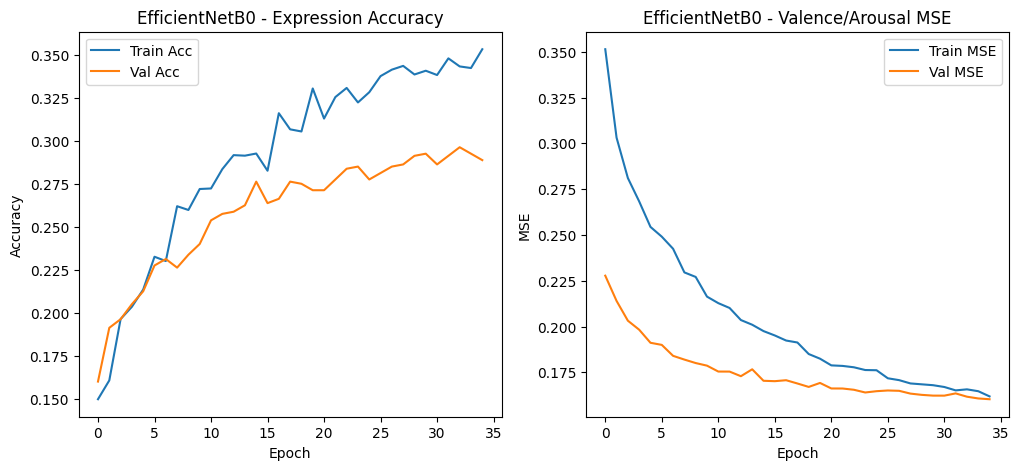

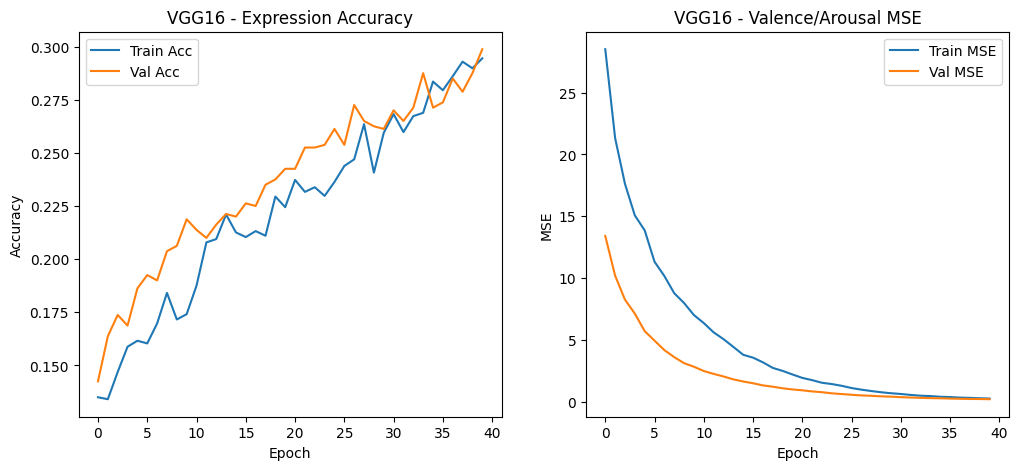

In [23]:
import matplotlib.pyplot as plt

def plot_history(hist, title):
    plt.figure(figsize=(12,5))

    # Classification accuracy
    plt.subplot(1,2,1)
    plt.plot(hist.history["exp_accuracy"], label="Train Acc")
    plt.plot(hist.history["val_exp_accuracy"], label="Val Acc")
    plt.title(f"{title} - Expression Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Regression MSE
    plt.subplot(1,2,2)
    plt.plot(hist.history["va_mse"], label="Train MSE")
    plt.plot(hist.history["val_va_mse"], label="Val MSE")
    plt.title(f"{title} - Valence/Arousal MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

# Plot both
plot_history(eff_hist, "EfficientNetB0")
plot_history(vgg_hist, "VGG16")


In [24]:
import pandas as pd

df = pd.DataFrame([eff_results, vgg_results], index=["EfficientNetB0", "VGG16"])
print(df)


                accuracy  f1_macro     kappa  roc_auc_macro  pr_auc_macro  \
EfficientNetB0   0.29625  0.293058  0.195714       0.722609      0.294355   
VGG16            0.29875  0.295231  0.198571       0.690595      0.259161   

                mse_valence  mse_arousal  rmse_valence  rmse_arousal  \
EfficientNetB0     0.196079     0.127273      0.442808      0.356753   
VGG16              0.283227     0.178209      0.532191      0.422148   

                corr_valence  corr_arousal  sagr_valence  sagr_arousal  \
EfficientNetB0      0.341720      0.330468       0.71125       0.79125   
VGG16               0.126622      0.155529       0.62625       0.74625   

                ccc_valence  ccc_arousal  
EfficientNetB0     0.223432     0.227818  
VGG16              0.117603     0.142249  


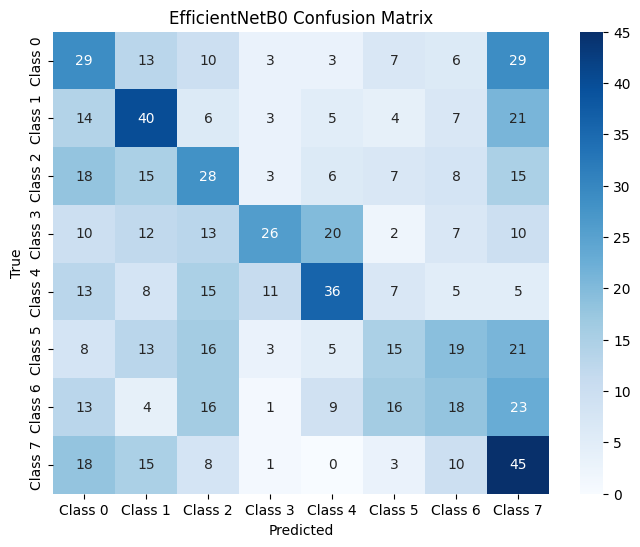

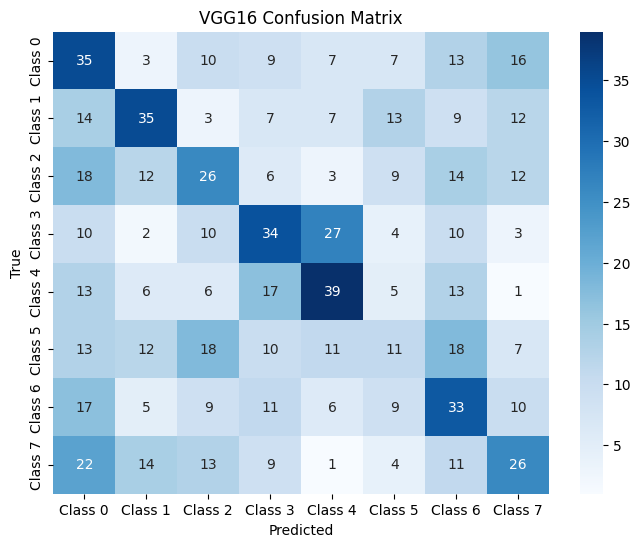

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_conf_matrix(model, ds, class_names, title="Confusion Matrix"):
    y_true, y_pred = [], []

    for xb, (yexp, yva) in ds:
        preds_exp, _ = model.predict(xb, verbose=0)
        y_true.extend(yexp.numpy())
        y_pred.extend(np.argmax(preds_exp, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Example usage (replace with your actual class labels if known)
class_names = [f"Class {i}" for i in range(num_classes)]

plot_conf_matrix(best_eff, ds_val, class_names, "EfficientNetB0 Confusion Matrix")
plot_conf_matrix(best_vgg, ds_val, class_names, "VGG16 Confusion Matrix")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


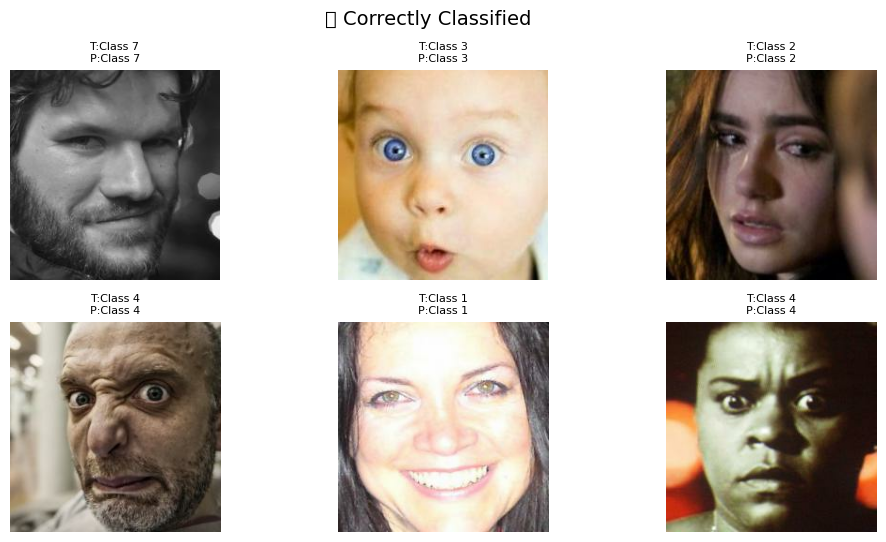

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


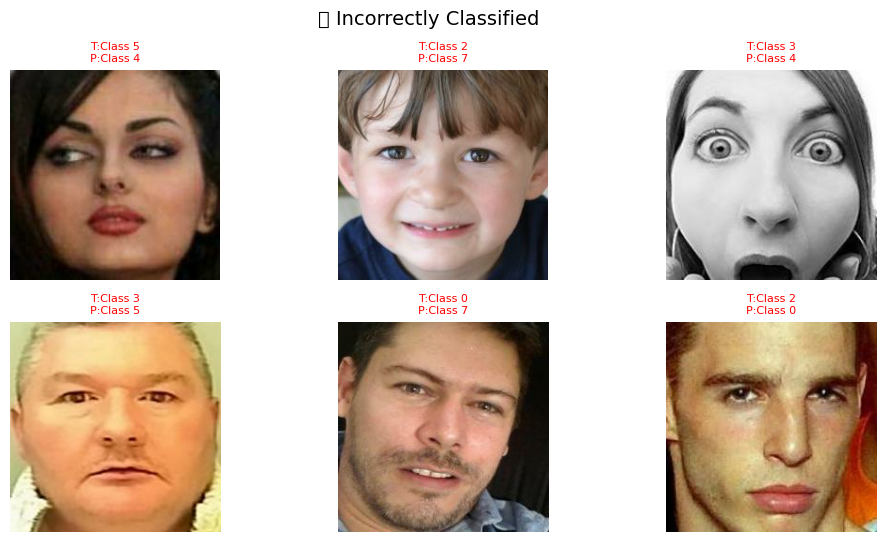

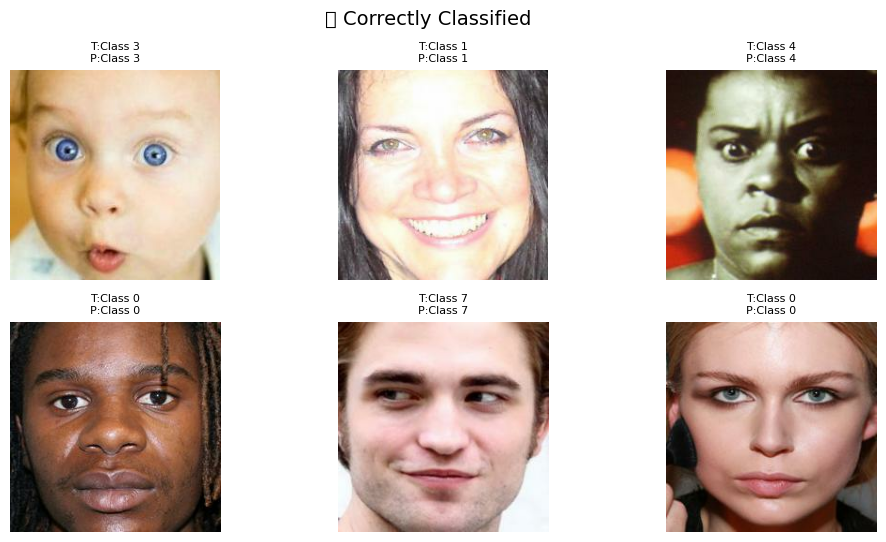

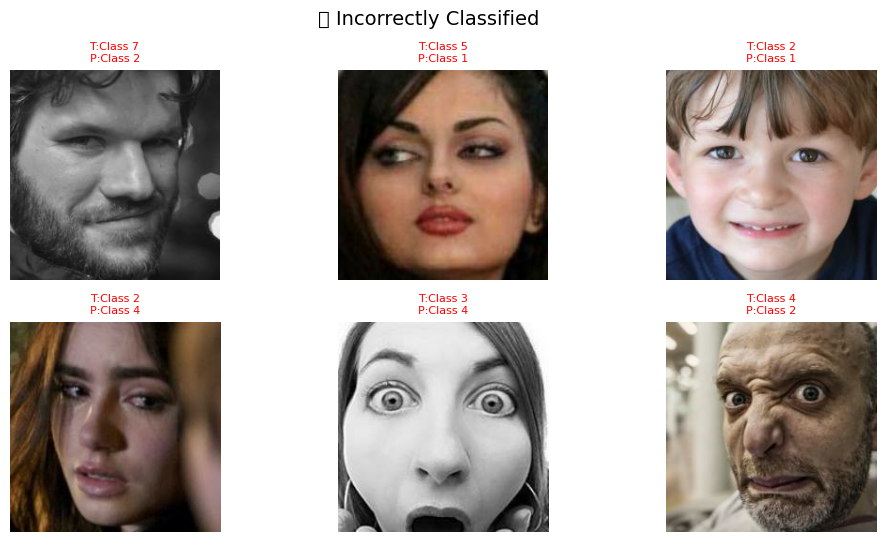

In [26]:
import matplotlib.pyplot as plt

def show_examples(model, ds, class_names, num_correct=6, num_incorrect=6):
    """
    Displays a grid of correct and incorrect classifications from the dataset.
    - model: trained classifier
    - ds: dataset (images + labels)
    - class_names: list of class names
    """
    imgs, trues, preds = [], [], []

    # collect one pass over dataset
    for xb, (yexp, yva) in ds.take(5):  # take a few batches
        pexp, _ = model.predict(xb, verbose=0)
        pred_labels = np.argmax(pexp, axis=1)
        imgs.extend(xb.numpy())
        trues.extend(yexp.numpy())
        preds.extend(pred_labels)

    imgs, trues, preds = np.array(imgs), np.array(trues), np.array(preds)

    # indices for correct / incorrect
    correct_idx = np.where(trues == preds)[0]
    wrong_idx   = np.where(trues != preds)[0]

    # plot correct
    plt.figure(figsize=(12, 6))
    plt.suptitle("✅ Correctly Classified", fontsize=14)
    for i, idx in enumerate(correct_idx[:num_correct]):
        plt.subplot(2, num_correct//2, i+1)
        plt.imshow(imgs[idx].astype("uint8"))
        plt.axis("off")
        plt.title(f"T:{class_names[trues[idx]]}\nP:{class_names[preds[idx]]}", fontsize=8)
    plt.show()

    # plot incorrect
    plt.figure(figsize=(12, 6))
    plt.suptitle("❌ Incorrectly Classified", fontsize=14)
    for i, idx in enumerate(wrong_idx[:num_incorrect]):
        plt.subplot(2, num_incorrect//2, i+1)
        plt.imshow(imgs[idx].astype("uint8"))
        plt.axis("off")
        plt.title(f"T:{class_names[trues[idx]]}\nP:{class_names[preds[idx]]}", fontsize=8, color="red")
    plt.show()

# 🔹 Call for each model
show_examples(best_vgg, ds_val, class_names, num_correct=6, num_incorrect=6)
show_examples(best_eff, ds_val, class_names, num_correct=6, num_incorrect=6)
